In [1]:
# ====================================================
# Libraries
# ====================================================

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp, cumulative_trapezoid, trapezoid
from scipy.interpolate import RegularGridInterpolator
from scipy.special import erf
from multiprocessing import Pool
import os
import time
import emcee
from getdist import MCSamples, plots
import matplotlib.pyplot as plt
from scipy.stats import chi2 as chi2_dist

In [2]:
# ====================================================
# Loading CC data
# ====================================================

cc_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/CC/CC_Hz_data.txt"
df_cc = pd.read_csv(cc_dat_path, sep=r"\s+")

z_cc  = df_cc["z_cc"].to_numpy(float)
H_obs = df_cc["H_cc"].to_numpy(float)
H_err = df_cc["H_cc_err"].to_numpy(float)


# ====================================================
# Loading SNe Ia data (Pantheon+SH0ES)
# ====================================================

sne_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/SNe/Pantheon+SH0ES.dat"
sne_cov_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/SNe/Pantheon+SH0ES_STAT+SYS.cov"

df_sne       = pd.read_csv(sne_dat_path, sep=r"\s+", comment="#", engine="python")
raw_cov      = np.loadtxt(sne_cov_path, skiprows=1)
Cov_sne_full = raw_cov.reshape((1701, 1701))

mask     = df_sne["zCMB"].values > 0.01
df_cut   = df_sne[mask].reset_index(drop=True)
Cov_sne  = Cov_sne_full[mask, :][:, mask]
z_sne    = df_cut["zCMB"].values
mB_obs   = df_cut["m_b_corr"].values

Cinv_sne = np.linalg.inv(Cov_sne)


# ========================================================
# Loading DESI BAO DR2 data
# ========================================================

bao_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/BAO/desi_gaussian_bao_ALL_GCcomb_mean.txt"
bao_cov_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/BAO/desi_gaussian_bao_ALL_GCcomb_cov.txt"

df_bao   = pd.read_csv(bao_dat_path, sep=r"\s+", comment="#", names=["z", "value", "quantity"])

z_bao    = df_bao["z"].values
d_obs    = df_bao["value"].values
q_bao    = df_bao["quantity"].str.lower().values

cov_bao  = np.loadtxt(bao_cov_path)
Cinv_bao = np.linalg.inv(cov_bao)


# ====================================================
# Loading FRB data
# ====================================================

frb_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/FRB/frb_catalog.txt"
df_frb       = pd.read_csv(frb_dat_path, sep=r"\t", engine="python")
df_frb       = df_frb.sort_values(by="Redshift", ascending=True).reset_index(drop=True)

z_frb        = df_frb["Redshift"].to_numpy(float)
DM_obs       = df_frb["DM_obs"].to_numpy(float)
DM_MW        = df_frb["DM_MW_ISM_(NE2001)"].to_numpy(float)
DM_MW_total  = DM_MW + 50.0          # MW ISM + halo contribution [pc/cm^3]
DM_ext_obs   = DM_obs - DM_MW_total  # extragalactic DM [pc/cm^3]

In [3]:
# ====================================================
# Fiducial / Priors
# ====================================================

# Uniform priors
H0_min,       H0_max       = 50.0,   90.0
Om0_min,      Om0_max      = 0.1,    0.6
Ob_min,       Ob_max       = 0.01,   0.1
MB_min,       MB_max       = -20.0,  -18.0
b_min,        b_max        = 1.6,    12.0
sig_host_min, sig_host_max = 0.2,   2.0
e_mu_min,     e_mu_max     = 20.0,  200.0

# Physical constants
c_kms = 299792.458         # speed of light [km/s]
c_si  = 2.99792458e8       # speed of light [m/s]
G_si  = 6.67430e-11        # gravitational constant [m^3 kg^-1 s^-2]
mp_si = 1.67262192369e-27  # proton mass [kg]

# Unit conversions
km_to_pc = 1.0 / (3.0857e13)
m2_to_cm2 = 1e4
Mpc_to_cm = 3.0857e24

# Astrophysical parameters
f_IGM = 0.83
chi_e = 0.875
Neff  = 3.046

# Scalaron mass scale
delta_s = 1e-7


# ====================================================
# Redshift / scale-factor grids
# ====================================================

ai, af = 0.2, 1.0
zi, zf = 0.0, 4.0
N_grid = 300
z_grid = np.linspace(zi, zf, N_grid)
dz     = np.diff(z_grid)

In [4]:
# ====================================================
# Curvature scale (ε) in AB f(R) gravity
# ====================================================

def compute_epsilon(H0, b):
    R_vac = 12.0 * H0**2
    L = np.log1p(np.exp(2.0 * b)) if b < 20.0 else 2.0 * b + np.exp(-2.0 * b)
    return R_vac / L


# ====================================================
# Custom exception for ODE failure
# ====================================================

class ODEFailure(Exception):
    pass


# ====================================================
# ODE system for H(a) in AB f(R) gravity
# ====================================================

def Hubble_AB_a(a, y, H0, Om0, b, epsilon, M2):
    """
    ODE system for H(a) in the AB f(R) model.
    epsilon and M2 are pre-computed outside the integrator.
    """
    
    H, dH, ddH = y

    Om    = Om0 * a**(-3)
    R     = 6.0 * H * (2.0 * H + a * dH)
    alpha = (R / epsilon) - b

    abs_a = abs(alpha)
    if abs_a < 20.0:
        tanh_a = np.tanh(alpha)
        sech_a = 1.0 / np.cosh(alpha)
    else:
        tanh_a = 1.0 if alpha > 0 else -1.0
        sech_a = 2.0 * np.exp(-abs_a)

    A = H0**2 * (3.0 * Om)
    B = a * H * dH * (tanh_a + 1.0)
    C = 4.0 * a * H**2 * dH * (a * dH + 2.0 * H) / M2
    D = ((6.0 * a**2 * H**2 / epsilon)**2
         * ((5.0 * dH / a) + (dH**2 / H) + ddH)**2
         * tanh_a * (sech_a**2))
    E = 6.0 * a**3 * H**3 * (1.0 / (3.0 * M2) + 0.5 * (sech_a**2) / epsilon)

    if E == 0 or not np.isfinite(E):
        raise ODEFailure(f"E singular or non-finite at a={a:.4f}")

    F = ((11.0 * dH**2) / (a * H) + (dH**3) / (H**2)
         + (6.0 * ddH / a) + (4.0 * dH * ddH / H))

    dddH = -(A + B + C - D) / E - F
    return [dH, ddH, dddH]


# ====================================================
# ODE integration → H(a)
# ====================================================

def H_AB_a(a_eval, H0, Om0, b):
    """
    Integrates the AB f(R) ODE system using DOP853.
    epsilon and M2 are pre-computed once and passed
    to the ODE to avoid per-step overhead.
    """
    
    epsilon = compute_epsilon(H0, b)
    M2      = epsilon / delta_s

    Omi  = Om0 * ai**(-3)
    Ol0  = 1.0 - Om0
    Hi   = H0 * np.sqrt(Omi + Ol0)
    dHi  = -(H0**2) / (2.0 * ai * Hi) * (3.0 * Omi)
    ddHi = (0.5 * (H0 / (ai * Hi))**2 * (Hi + ai * dHi) * (3.0 * Omi)
            + 0.5 * (H0 / (ai * Hi))**2 * Hi * (9.0 * Omi))

    y0 = [Hi, dHi, ddHi]

    try:
        sol = solve_ivp(
            Hubble_AB_a,
            (ai, af),
            y0,
            t_eval=a_eval,
            method="DOP853",
            rtol=1e-5,
            atol=1e-8,
            args=(H0, Om0, b, epsilon, M2),
            dense_output=False
        )
    except ODEFailure:
        return None

    if sol.status < 0 or np.any(~np.isfinite(sol.y)):
        return None

    return sol.y[0]


# ====================================================
# H(z) via a = 1/(1+z) conversion
# ====================================================

def H_AB_z(z_eval, H0, Om0, b):
    """
    Converts z → a, integrates H(a) over [ai, af], and
    returns H(z) in the original ordering of z_eval.
    Points outside the integration domain receive NaN.
    Duplicate a-values are removed before integration
    to avoid instabilities in solve_ivp.
    """

    z_eval = np.atleast_1d(np.asarray(z_eval, dtype=float))
    a_eval = 1.0 / (1.0 + z_eval)

    in_domain = (a_eval >= ai) & (a_eval <= af)
    if not np.any(in_domain):
        return None

    valid_idx = np.where(in_domain)[0]
    a_valid   = a_eval[valid_idx]

    sort_idx    = np.argsort(a_valid)
    a_sorted    = a_valid[sort_idx]
    unique_mask = np.concatenate(([True], np.diff(a_sorted) > 1e-12))
    a_unique    = a_sorted[unique_mask]

    H_unique = H_AB_a(a_unique, H0, Om0, b)
    if H_unique is None:
        return None

    if not np.all(unique_mask):
        H_at_sorted = np.interp(a_sorted, a_unique, H_unique)
    else:
        H_at_sorted = H_unique

    H_valid           = np.empty(len(a_valid))
    H_valid[sort_idx] = H_at_sorted

    H_z            = np.full(len(z_eval), np.nan)
    H_z[valid_idx] = H_valid

    return H_z

In [5]:
# ====================================================
# Worker function (module level — required for pickle)
# ====================================================

# def _grid_worker(args):
#    """
#    Computes H(z) for a single (H0, Om0, b) grid point.
#    Returns (i, j, k, H_values) or (i, j, k, None) on failure.
#    """

#    i, j, k, H0, Om0, b, z_pts = args
#    Hvals = H_AB_z(z_pts, H0, Om0, b)
#    if Hvals is not None and np.all(np.isfinite(Hvals)):
#        return (i, j, k, Hvals)
#    else:
#        return (i, j, k, None)


# ====================================================
# Parallel grid builder
# ====================================================

#def build_H_grid_parallel(H0_pts, Om0_pts, b_pts, z_pts,
#                           n_cores=None, verbose=True):
#    """
#    Builds the 4D array H[i_H0, i_Om0, i_b, i_z] in parallel
#    using multiprocessing.Pool.
#    """

#    nH  = len(H0_pts)
#    nOm = len(Om0_pts)
#    nb  = len(b_pts)
#    nz  = len(z_pts)

#    total   = nH * nOm * nb
#    n_cores = n_cores or os.cpu_count()

#    tasks = [
#        (i, j, k, H0, Om0, b, z_pts)
#        for i, H0  in enumerate(H0_pts)
#        for j, Om0 in enumerate(Om0_pts)
#        for k, b   in enumerate(b_pts)
#    ]

#    H_array   = np.full((nH, nOm, nb, nz), np.nan)
#    nan_count = 0

#    if verbose:
#        print(f"  Total grid points : {total} ({nH}×{nOm}×{nb})")
#        print(f"  Workers           : {n_cores}")
#        print(f"  {'PCT':>5}  {'Done':>8}  {'Elapsed':>9}  {'ETA':>9}  {'Rate':>12}")
#        print("  " + "-"*55)

#    t0       = time.time()
#    count    = 0
#    last_pct = -1
#    chunksize = max(1, total // (n_cores * 20))

#    with Pool(processes=n_cores) as pool:
#        for result in pool.imap_unordered(_grid_worker, tasks,
#                                           chunksize=chunksize):
#            i, j, k, Hvals = result
#            if Hvals is not None:
#                H_array[i, j, k, :] = Hvals
#            else:
#                nan_count += 1

#            count   += 1
#            elapsed  = time.time() - t0
#            pct      = int(count / total * 100)

#            if verbose and (pct >= last_pct + 10 or count == total):
#                eta  = (elapsed / count) * (total - count) if count < total else 0.0
#                rate = count / elapsed if elapsed > 0 else 0.0
#                print(f"  {pct:>4}%  {count:>8}/{total}  "
#                      f"{elapsed:>7.1f}s  "
#                      f"ETA {eta:>6.1f}s  "
#                      f"{rate:>8.1f} pts/s")
#                last_pct = pct

#    nan_frac = nan_count / total
#    if nan_frac > 0:
#        print(f"\n  ⚠  {100*nan_frac:.1f}% NaN in grid — "
#              f"check prior bounds or ODE stability.")
#    else:
#        print(f"\n  ✓  Grid complete with no NaN points.")

#    total_time = time.time() - t0
#    print(f"  Total time: {total_time:.1f}s ({total_time/60:.2f} min)")

#    return H_array


# ====================================================
# Interpolation error validation
# ====================================================

# def validate_interpolation_error(H_interp_4D, H0_pts, Om0_pts, b_pts, z_pts,
#                                  n_test=300, tol_percent=0.5):
#    """
#    Validates the interpolator against direct ODE solutions at
#    n_test random interior points.
#    """

#    rng_v  = np.random.default_rng(0)
#    errors = []

#    for _ in range(n_test):
#        H0_t  = rng_v.uniform(H0_pts[1],  H0_pts[-2])
#        Om0_t = rng_v.uniform(Om0_pts[1], Om0_pts[-2])
#        b_t   = rng_v.uniform(b_pts[1],   b_pts[-2])

#        H_true = H_AB_z(z_pts, H0_t, Om0_t, b_t)
#        if H_true is None or not np.all(np.isfinite(H_true)):
#            continue

#        pts      = np.column_stack([np.full(len(z_pts), H0_t),
#                                    np.full(len(z_pts), Om0_t),
#                                    np.full(len(z_pts), b_t),
#                                    z_pts])
#        H_interp = H_interp_4D(pts)
#        rel_err  = np.abs((H_true - H_interp) / H_true) * 100.0
#        errors.append(np.max(rel_err))

#   errors = np.array(errors)

#    print(f"\n  Interpolation validation ({n_test} random interior points):")
#    print(f"  Max error    : {errors.max():.4f}%")
#    print(f"  Median error : {np.median(errors):.4f}%")
#    print(f"  95th pct     : {np.percentile(errors, 95):.4f}%")

#    if errors.max() < tol_percent:
#        print(f"  ✓  Interpolator approved (max error < {tol_percent}%). "
#              f"Ready for MCMC.")
#    else:
#        print(f"  ✗  Max error exceeds {tol_percent}%! "
#              f"Increase grid resolution (n_H0, n_Om0, n_b).")

#    return errors


# ====================================================
# 4D interpolation grid parameters
# ====================================================

# n_H0  = 30
# n_Om0 = 30
# n_b   = 30

# H0_grid_pts  = np.linspace(H0_min,  H0_max,  n_H0)
# Om0_grid_pts = np.linspace(Om0_min, Om0_max, n_Om0)
# b_grid_pts   = np.linspace(b_min,   b_max,   n_b)


# ====================================================
# Build grid (parallel)
# ====================================================

# print("\n=== Building 4D interpolation grid (parallel) ===")
# H_array = build_H_grid_parallel(
#    H0_grid_pts, Om0_grid_pts, b_grid_pts, z_grid,
#    n_cores=None
#)


# ====================================================
# Build interpolator
# ====================================================

# H_interp_4D = RegularGridInterpolator(
#    (H0_grid_pts, Om0_grid_pts, b_grid_pts, z_grid),
#    H_array,
#    method="linear",
#    bounds_error=False,
#    fill_value=np.nan
#)


# ====================================================
# Validate interpolator
# ====================================================

# print("\n=== Validating interpolator ===")
# errors = validate_interpolation_error(
#    H_interp_4D, H0_grid_pts, Om0_grid_pts, b_grid_pts, z_grid
# )


# ====================================================
# Save grid to disk
# ====================================================

# print("\n=== Saving grid to disk ===")

# np.savez_compressed(
#    "Hgrid_AB_30x30x30.npz",
#    H_array=H_array, # H_array.astype(np.float32),   # opcional: reduz tamanho
#    H0_grid_pts=H0_grid_pts,
#    Om0_grid_pts=Om0_grid_pts,
#    b_grid_pts=b_grid_pts,
#    z_grid=z_grid
# )

# print("✓ Grid saved successfully!")

In [6]:
# ====================================================
# Load precomputed grid
# ====================================================

print("\n=== Loading precomputed grid ===")

data = np.load("../CC_SNe_BAO/Hgrid_AB_30x30x30.npz")

H_array       = data["H_array"]
H0_grid_pts   = data["H0_grid_pts"]
Om0_grid_pts  = data["Om0_grid_pts"]
b_grid_pts    = data["b_grid_pts"]
z_grid        = data["z_grid"]

print("✓ Grid loaded successfully!")

# ====================================================
# Rebuild interpolator
# ====================================================

H_interp_4D = RegularGridInterpolator(
    (H0_grid_pts, Om0_grid_pts, b_grid_pts, z_grid),
    H_array,
    method="linear",
    bounds_error=False,
    fill_value=np.nan
)

# ====================================================
# Hubble function (interpolated)
# ====================================================

def H_AB_interp(z_eval, H0, Om0, b):
    z_eval = np.atleast_1d(z_eval)

    pts = np.column_stack([
        np.full(len(z_eval), H0),
        np.full(len(z_eval), Om0),
        np.full(len(z_eval), b),
        z_eval
    ])

    return H_interp_4D(pts)


=== Loading precomputed grid ===
✓ Grid loaded successfully!


In [7]:
# ====================================================
# Hubble function (interpolated) 
# Used inside MCMC likelihood
# ====================================================

# def H_AB_interp(z_eval, H0, Om0, b):
#     pts = np.column_stack([
#         np.full(len(z_eval), H0),
#         np.full(len(z_eval), Om0),
#         np.full(len(z_eval), b),
#         z_eval
#     ])
#     return H_interp_4D(pts)


# ========================================================
# Apparent magnitude (interpolated) 
# Used inside MCMC likelihood
# ========================================================

def dL_AB_interp(z, H0, Om0, b):
    H_interp   = H_AB_interp(z_grid, H0, Om0, b)
    prefactor  = c_kms * (1.0 + z)
    integrand  = 1.0 / H_interp
    integral   = cumulative_trapezoid(integrand, z_grid, initial=0.0)
    integral_z = np.interp(z, z_grid, integral)
    return prefactor * integral_z

def mB_AB_interp(z, H0, Om0, MB, b):
    dL_interp = dL_AB_interp(z, H0, Om0, b)
    mu = 5.0 * np.log10(dL_interp) + 25.0
    return mu + MB


# ====================================================
# BAO observables (interpolated) 
# Used inside MCMC likelihood
# ====================================================

def comoving_dist_interp(z, H0, Om0, b):
    H_interp  = H_AB_interp(z_grid, H0, Om0, b)
    integrand = 1.0 / H_interp
    integral     = np.empty_like(z_grid)
    integral[0]  = 0.0
    integral[1:] = np.cumsum(0.5 * (integrand[1:] + integrand[:-1]) * dz)
    I_z = np.interp(z, z_grid, integral)
    return c_kms * I_z

def d_bao_AB_interp(z_arr, q_arr, H0, Om0, Ob, b):
    h2   = (H0 / 100.0)**2
    Obh2 = Ob * h2
    Omh2 = Om0 * h2
    rd   = 147.05 * ((Obh2 / 0.02236)**-0.13) \
                  * ((Omh2 / 0.1432)**-0.23) \
                  * ((Neff / 3.04)**-0.1)
    dC  = comoving_dist_interp(z_arr, H0, Om0, b)
    H_z = H_AB_interp(z_arr, H0, Om0, b)
    dm = dC / rd
    dh = (c_kms / H_z) / rd
    dv = (z_arr * dm**2 * dh)**(1.0 / 3.0)
    d_bao          = np.empty_like(z_arr)
    mask_dv        = np.array(["dv" in q for q in q_arr])
    mask_dm        = np.array(["dm" in q for q in q_arr])
    mask_dh        = np.array(["dh" in q for q in q_arr])
    d_bao[mask_dv] = dv[mask_dv]
    d_bao[mask_dm] = dm[mask_dm]
    d_bao[mask_dh] = dh[mask_dh]
    return d_bao


# ====================================================
# Theoretical IGM dispersion measure (interpolated) 
# Used inside MCMC likelihood
# ====================================================

def DM_IGM_AB_interp(z, H0, Om0, Ob, b):
    prefactor = 3.0 * c_si * f_IGM * chi_e / (8.0 * np.pi * G_si * mp_si)
    H_interp   = H_AB_interp(z_grid, H0, Om0, b)
    integrand  = (1 + z_grid) / H_interp
    I_interp   = cumulative_trapezoid(integrand, z_grid, initial=0.0)
    I_z_interp = np.interp(z, z_grid, I_interp)
    DM_IGM_interp  = prefactor * Ob * H0**2 * I_z_interp        
    DM_corr_interp = DM_IGM_interp * (km_to_pc / (m2_to_cm2 * Mpc_to_cm)) 
    return DM_corr_interp

In [8]:
# ====================================================
# CC + SNe + BAO + FRB likelihood
# ====================================================

# Toggle: Choose a prior for b
USE_LOG_b_PRIOR = False   # True = Jeffreys (log b) | False = Uniform (b)

# Bounds
if USE_LOG_b_PRIOR:
    b_param_min = np.log(b_min)
    b_param_max = np.log(50.0)
else:
    b_param_min = b_min
    b_param_max = b_max


# Log-prior
def lnprior_cc_sne_bao_frb(theta):
    H0, Om0, Ob, MB, b_param, sigma_host, exp_mu = theta
    if not (H0_min       <= H0         <= H0_max):       return -np.inf
    if not (Om0_min      <= Om0        <= Om0_max):      return -np.inf
    if not (Ob_min       <= Ob         <= Ob_max):       return -np.inf
    if not (MB_min       <= MB         <= MB_max):       return -np.inf
    if not (b_param_min  <= b_param    <= b_param_max):  return -np.inf
    if not (sig_host_min <= sigma_host <= sig_host_max): return -np.inf
    if not (e_mu_min     <= exp_mu     <= e_mu_max):     return -np.inf
    return 0.0


# Convolved FRB PDF: IGM (Gaussian) + host galaxy (log-normal)
def P_DM_ext_vectorized(z_frb, DM_ext_obs, DM_IGM_mean, sigma_IGM,
                         sigma_host, exp_mu, npts=300):

    mu_host      = np.log(exp_mu)
    upper        = max(DM_ext_obs.max(), 5.0 * exp_mu)
    DM_hosp_grid = np.linspace(1e-2, upper, npts)
    DM_hosp_grid = DM_hosp_grid[None, :]                       
    DM_ext_array      = DM_ext_obs[:, None]                  
    DM_IGM_array      = DM_ext_array - DM_hosp_grid / (1 + z_frb[:, None])  
    sigma_IGM_array   = sigma_IGM[:, None]
    DM_IGM_mean_array = DM_IGM_mean[:, None]
    
    # standardized variable
    y = (DM_IGM_array - DM_IGM_mean_array) / sigma_IGM_array

    # standard normal PDF
    phi = (1/np.sqrt(2*np.pi)) * np.exp(-0.5 * y**2)

    # normalization factor: 1 - Φ(0 | μ, σ) = Φ(μ/σ)
    norm_factor = 0.5 * (1 + erf(DM_IGM_mean_array / (sigma_IGM_array * np.sqrt(2))))

    # truncated Gaussian
    P_IGM = (1 / sigma_IGM_array) * phi / norm_factor
    P_IGM[DM_IGM_array < 0] = 0.0
    
    DM_hosp_array = DM_hosp_grid
    P_host = (1.0 / (np.sqrt(2*np.pi) * sigma_host * DM_hosp_array)) \
             * np.exp(-0.5 * ((np.log(DM_hosp_array) - mu_host) / sigma_host)**2)
    
    integrand = P_IGM * P_host                                 
    P_total   = trapezoid(integrand, x=DM_hosp_grid[0], axis=1)
    return np.maximum(P_total, 1e-100)


# Joint likelihood
def lnlike_cc_sne_bao_frb(theta, z_cc, H_obs, H_err,
                          z_sne, mB_obs, Cinv_sne,
                          z_bao, d_obs, q_bao, Cinv_bao,
                          z_frb, DM_ext_obs):
    
    H0, Om0, Ob, MB, b_param, sigma_host, exp_mu = theta
    b = np.exp(b_param) if USE_LOG_b_PRIOR else b_param
    
    # --- CC ---
    H_model = H_AB_interp(z_cc, H0, Om0, b)
    if not np.all(np.isfinite(H_model)):
        return -np.inf
    lnL_cc =  -0.5 * np.sum(((H_obs - H_model) / H_err)**2)

    # --- SNe ---
    mB_model = mB_AB_interp(z_sne, H0, Om0, MB, b)
    if not np.all(np.isfinite(mB_model)):
        return -np.inf
    resid_sne = mB_obs - mB_model
    lnL_sne   = -0.5 * (resid_sne @ Cinv_sne @ resid_sne)

    # --- BAO ---
    d_model = d_bao_AB_interp(z_bao, q_bao, H0, Om0, Ob, b)
    if not np.all(np.isfinite(d_model)):
        return -np.inf
    resid_bao = d_obs - d_model
    lnL_bao   = -0.5 * (resid_bao @ Cinv_bao @ resid_bao)

    ## --- FRB ---
    DM_IGM_mean = DM_IGM_AB_interp(z_frb, H0, Om0, Ob, b)
    if not np.all(np.isfinite(DM_IGM_mean)):
        return -np.inf
    sigma_IGM = 173.8 * (z_frb**0.4)
    P_total   = P_DM_ext_vectorized(z_frb, DM_ext_obs, DM_IGM_mean,
                                     sigma_IGM, sigma_host, exp_mu)
    lnL_frb   = np.sum(np.log(P_total))
    return lnL_cc + lnL_sne + lnL_bao + lnL_frb


# Joint posterior
def lnprob_cc_sne_bao_frb(theta, z_cc, H_obs, H_err,
                          z_sne, mB_obs, Cinv_sne,
                          z_bao, d_obs, q_bao, Cinv_bao,
                          z_frb, DM_ext_obs):
    
    lp = lnprior_cc_sne_bao_frb(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike_cc_sne_bao_frb(theta, z_cc, H_obs, H_err,
                          z_sne, mB_obs, Cinv_sne,
                          z_bao, d_obs, q_bao, Cinv_bao,
                          z_frb, DM_ext_obs)


# ====================================================
# Quick test
# ====================================================

b_test     = np.log(2.5) if USE_LOG_b_PRIOR else 2.5
theta_test = [70.0, 0.3, 0.0495, -19.24, b_test, 0.7, 120]
print(f"Prior type : {'Jeffreys (log b)' if USE_LOG_b_PRIOR else 'Uniform (b)'}")
print("CC + SNe + BAO + FRB log-posterior =",
      lnprob_cc_sne_bao_frb(theta_test, z_cc, H_obs, H_err,
                          z_sne, mB_obs, Cinv_sne,
                          z_bao, d_obs, q_bao, Cinv_bao,
                          z_frb, DM_ext_obs))

Prior type : Uniform (b)
CC + SNe + BAO + FRB log-posterior = -1467.0434880366556


In [9]:
# ====================================================
# MCMC configuration
# ====================================================

ndim     = 7
nwalkers = 56
nsteps   = 80000

b_init = np.log(5.0) if USE_LOG_b_PRIOR else 5.0
bscale = 0.3         if USE_LOG_b_PRIOR else 0.1

theta0 = np.array([70.0, 0.3, 0.0495, -19.24, b_init, 0.7, 120.0])
scales = np.array([ 2.0, 0.02, 0.001,   0.02, bscale, 0.1,  10.0])

rng = np.random.default_rng(42)
p0  = theta0 + scales * rng.standard_normal((nwalkers, ndim))

for i in range(nwalkers):
    while not np.isfinite(lnprior_cc_sne_bao_frb(p0[i])):
        p0[i] = theta0 + scales * rng.standard_normal(ndim)


# ====================================================
# MCMC run
# ====================================================

print(f"\n=== Running MCMC (CC + SNe + BAO + FRB | {'Jeffreys' if USE_LOG_b_PRIOR else 'Uniform'} prior) ===")
t_mcmc = time.time()

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, lnprob_cc_sne_bao_frb,
    args=(z_cc, H_obs, H_err,
          z_sne, mB_obs, Cinv_sne,
          z_bao, d_obs, q_bao, Cinv_bao,
          z_frb, DM_ext_obs)
)
sampler.run_mcmc(p0, nsteps, progress=True)

print(f"\nMCMC completed in {(time.time() - t_mcmc) / 60:.1f} min")


=== Running MCMC (CC + SNe + BAO + FRB | Uniform prior) ===


100%|██████████| 80000/80000 [2:36:51<00:00,  8.50it/s]  


MCMC completed in 156.9 min


In [10]:
# ====================================================
# Convergence diagnostics
# ====================================================

print("\n=== Convergence diagnostics ===")

chain        = sampler.get_chain()
nsteps_total = chain.shape[0]

acc_frac = np.mean(sampler.acceptance_fraction)
print(f"Mean acceptance fraction: {acc_frac:.3f}")
if   0.2  <= acc_frac <= 0.5:  acc_status = "IDEAL"
elif 0.15 <= acc_frac <= 0.6:  acc_status = "ACCEPTABLE"
else:                           acc_status = "PROBLEMATIC"
print(f"Acceptance status: {acc_status}")

tau          = sampler.get_autocorr_time(tol=0)
tau_max      = np.max(tau)
length_ratio = nsteps_total / tau_max
print(f"\nMax autocorrelation time τ_max = {tau_max:.2f}")
print(f"Chain length / τ_max           = {length_ratio:.1f}")
length_status = "PASSED" if length_ratio >= 50 else "FAILED"
print(f"Length criterion (>50×τ)       : {length_status}")

nburn     = int(3 * tau_max)
nthin     = max(1, int(tau_max / 2))
n_post    = nsteps_total - nburn
N_eff     = nwalkers * (n_post / tau)
N_eff_min = np.min(N_eff)
print(f"\nBurn-in (3×τ_max)              = {nburn} steps ({100*nburn/nsteps_total:.1f}%)")
print(f"Thin (τ_max/2)                 = {nthin}")
print(f"Minimum N_eff                  = {int(N_eff_min)}")
if   N_eff_min >= 2000: eff_status = "EXCELLENT"
elif N_eff_min >= 1000: eff_status = "VERY GOOD"
elif N_eff_min >= 500:  eff_status = "ACCEPTABLE"
else:                   eff_status = "LOW"
print(f"Sampling quality               : {eff_status}")

if acc_status != "PROBLEMATIC" and length_status == "PASSED" and N_eff_min >= 500:
    print("\nCONVERGENCE STATUS: ✅ PASSED")
else:
    print("\nCONVERGENCE STATUS: ❌ NOT RELIABLE")


=== Convergence diagnostics ===
Mean acceptance fraction: 0.427
Acceptance status: IDEAL

Max autocorrelation time τ_max = 345.98
Chain length / τ_max           = 231.2
Length criterion (>50×τ)       : PASSED

Burn-in (3×τ_max)              = 1037 steps (1.3%)
Thin (τ_max/2)                 = 172
Minimum N_eff                  = 12781
Sampling quality               : EXCELLENT

CONVERGENCE STATUS: ✅ PASSED


In [11]:
# ====================================================
# Chain extraction — converter log_b → b if needed
# ====================================================

# flat_log    = sampler.get_chain(discard=nburn, thin=nthin, flat=True)       # Apply thin
flat_log      = sampler.get_chain(discard=nburn, flat=True)                   # No thin
flat_samples  = flat_log.copy()
if USE_LOG_b_PRIOR:
    flat_samples[:, 4] = np.exp(flat_log[:, 4])

# Save flat samples
fname = "flat_samples_AB_cc_sne_bao_frb_jeff.npy" if USE_LOG_b_PRIOR else "flat_samples_AB_cc_sne_bao_frb.npy"
np.save(fname, flat_samples)

# Save log-posterior (enables MAP in future sessions)
fname_lp = "log_prob_AB_cc_sne_bao_frb_jeff.npy" if USE_LOG_b_PRIOR else "log_prob_AB_cc_sne_bao_frb.npy"
log_prob_flat = sampler.get_log_prob(discard=nburn, flat=True)
np.save(fname_lp, log_prob_flat)

print(f"\nFinal independent samples : {len(flat_samples)}")
print(f"Burn-in used                : {nburn} steps")
print(f"Saved to                    : {fname}")
print(f"Log-posterior saved to      : {fname_lp}")


Final independent samples : 4421928
Burn-in used                : 1037 steps
Saved to                    : flat_samples_AB_cc_sne_bao_frb.npy
Log-posterior saved to      : log_prob_AB_cc_sne_bao_frb.npy


Removed no burn in


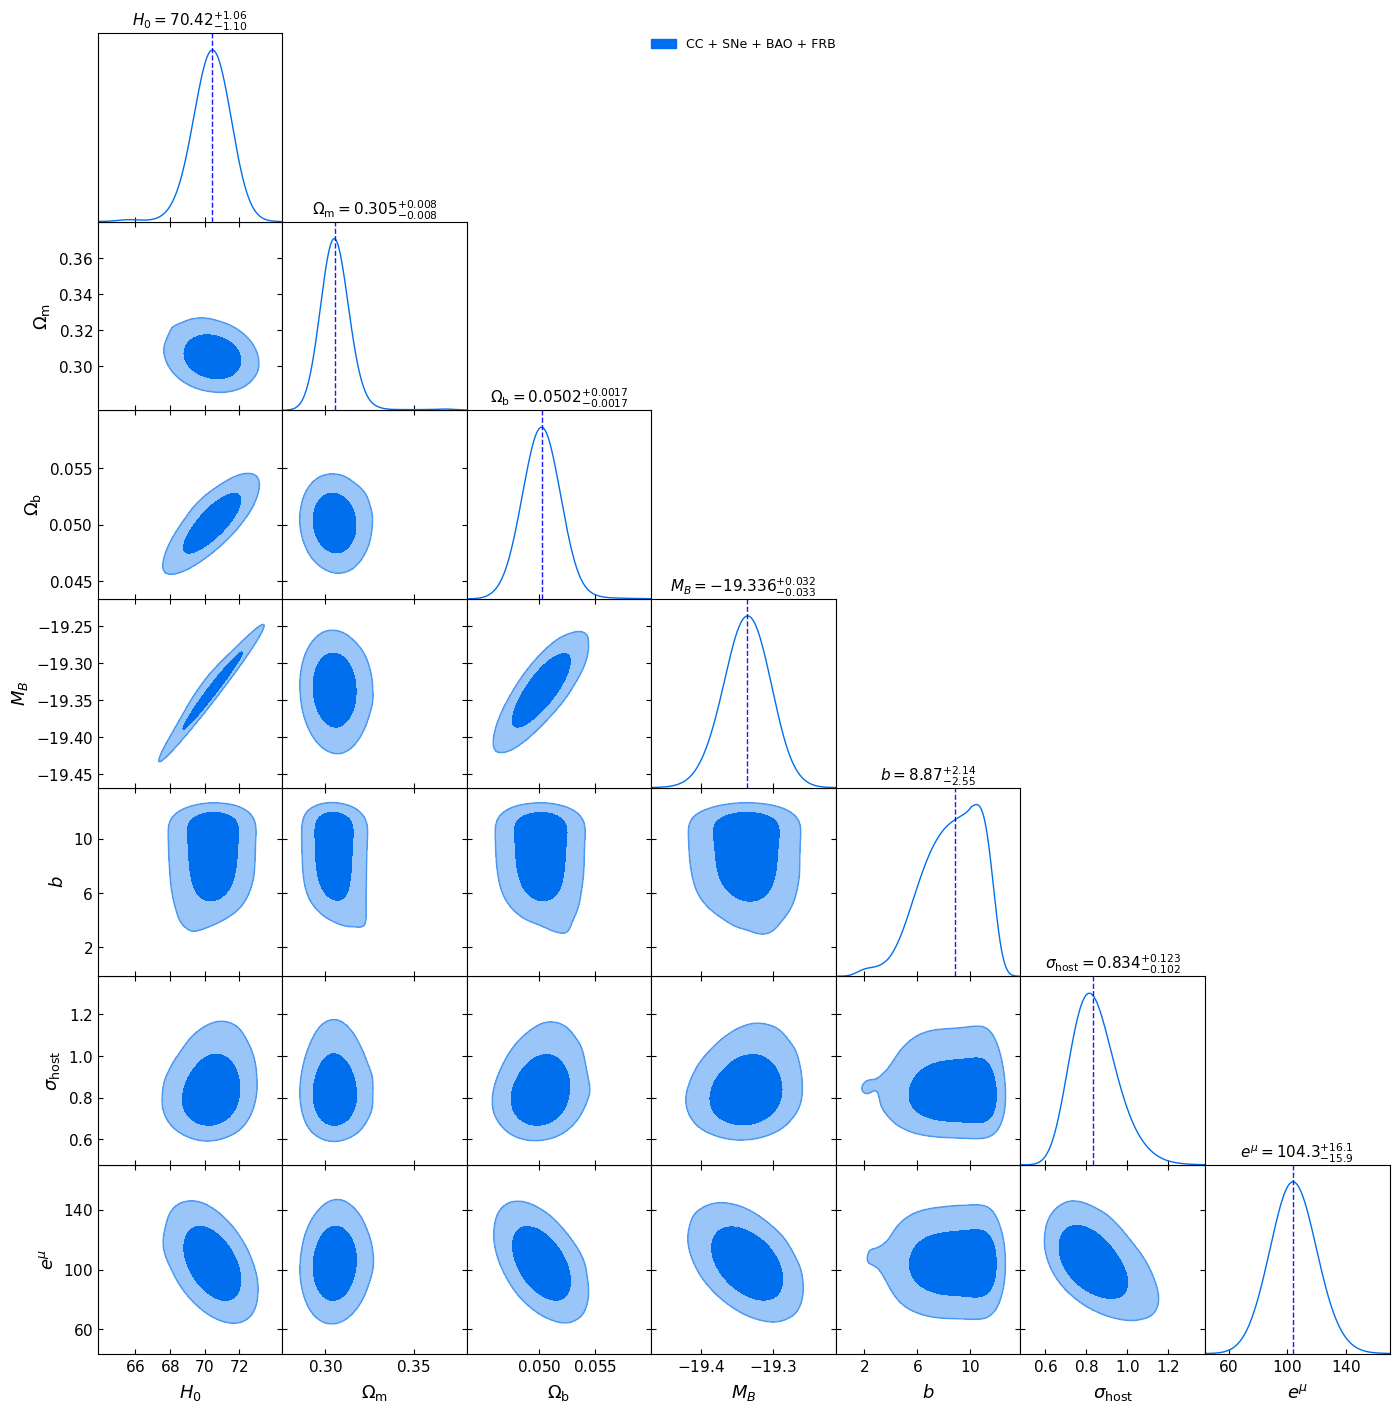

In [12]:
# ====================================================
# Corner plot (GetDist)
# ====================================================

param_names  = ["H0", "Om0", "Ob", "MB", "b", "sigma_host", "exp_mu"]
param_labels = [r"H_0", r"\Omega_{\rm m}", r"\Omega_{\rm b}", r"M_B", r"b",
                r"\sigma_{\rm host}", r"e^\mu"]

samples_gd = MCSamples(
    samples=flat_samples,
    names=param_names,
    labels=param_labels
)

samples_gd.updateSettings({
    "smooth_scale_1D": 0.35,
    "smooth_scale_2D": 0.35,
    "fine_bins":       1024,
    "fine_bins_2D":    1024,
})

g = plots.get_subplot_plotter()
g.settings.axes_fontsize       = 14
g.settings.lab_fontsize        = 16
g.settings.legend_fontsize     = 12
g.settings.linewidth_contour   = 2.0
g.settings.num_plot_contours   = 2
g.settings.axis_marker_lw      = 1.0
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add    = 0.3
g.triangle_plot(samples_gd, filled=True,
                legend_labels=["CC + SNe + BAO + FRB"],
                title_limit=0)

# ---- Fill under curve and add titles from samples ----
fmt_map = {"H0": ".2f", "Om0": ".3f", "Ob": ".4f", "MB": ".3f",
           "b": ".2f", "sigma_host": ".3f", "exp_mu": ".1f"}

for i, name in enumerate(param_names):
    samples = flat_samples[:, i]
    median  = np.percentile(samples, 50)
    lower68 = np.percentile(samples, 16)
    upper68 = np.percentile(samples, 84)
    ep68    = upper68 - median
    em68    = median  - lower68
    ax   = g.subplots[i, i]
    line = ax.get_lines()[0]
    line.set_linewidth(1.0)

    # Median line
    ax.axvline(median, color="blue", lw=1.0, ls="--", alpha=0.9)

    # Add title from samples
    fmt   = fmt_map[name]
    title = f"${param_labels[i]} = {median:{fmt}}^{{+{ep68:{fmt}}}}_{{-{em68:{fmt}}}}$"
    ax.set_title(title, fontsize=11, pad=4)
    
plt.subplots_adjust(top=0.95)
figname = "Corner_AB_cc_sne_bao_frb_jeff.png" if USE_LOG_b_PRIOR else "Corner_AB_cc_sne_bao_frb.png"
plt.savefig(figname, dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# ====================================================
# Marginalized statistics
# ====================================================

param_names_indices = [("H0", 0), ("Om0", 1), ("Ob", 2), ("MB", 3),
                       ("b", 4), ("sigma_host", 5), ("exp_mu", 6)]
fmt_map = {"H0": ".2f", "Om0": ".3f", "Ob": ".4f", "MB": ".3f",
           "b": ".2f", "sigma_host": ".3f", "exp_mu": ".1f"}

print("\n" + "="*60)
print(f"{'Final Inference Results (AB model | CC + SNe + BAO + FRB data)':^60}")
print("="*60)

for name, idx in param_names_indices:
    samples = flat_samples[:, idx]
    median  = np.percentile(samples, 50)
    lower68 = np.percentile(samples, 16)
    upper68 = np.percentile(samples, 84)
    lower95 = np.percentile(samples, 2.5)
    upper95 = np.percentile(samples, 97.5)
    ep68    = upper68 - median
    em68    = median  - lower68
    ep95    = upper95 - median
    em95    = median  - lower95
    fmt     = fmt_map[name]
    print(f"\n  {name}:")
    print(f"    {median:{fmt}} +{ep68:{fmt}} -{em68:{fmt}}  (68% CL)")
    print(f"    {median:{fmt}} +{ep95:{fmt}} -{em95:{fmt}}  (95% CL)")
    
print("\n" + "="*60)


Final Inference Results (AB model | CC + SNe + BAO + FRB data)

  H0:
    70.42 +1.06 -1.10  (68% CL)
    70.42 +2.05 -2.36  (95% CL)

  Om0:
    0.305 +0.008 -0.008  (68% CL)
    0.305 +0.019 -0.015  (95% CL)

  Ob:
    0.0502 +0.0017 -0.0017  (68% CL)
    0.0502 +0.0035 -0.0034  (95% CL)

  MB:
    -19.336 +0.032 -0.033  (68% CL)
    -19.336 +0.062 -0.066  (95% CL)

  b:
    8.87 +2.14 -2.55  (68% CL)
    8.87 +2.98 -5.01  (95% CL)

  sigma_host:
    0.834 +0.123 -0.102  (68% CL)
    0.834 +0.266 -0.185  (95% CL)

  exp_mu:
    104.3 +16.1 -15.9  (68% CL)
    104.3 +32.5 -31.0  (95% CL)



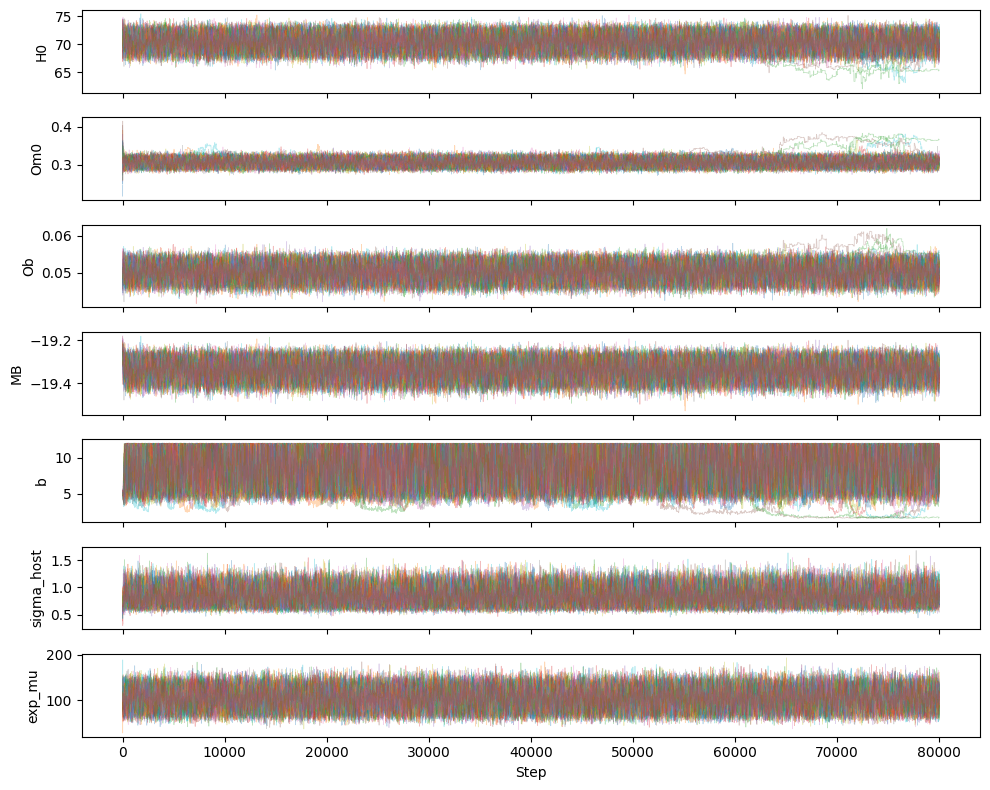

In [14]:
# ====================================================
# Walker chains
# ====================================================

chain_plot = sampler.get_chain().copy()

if USE_LOG_b_PRIOR:
    chain_plot[:, :, 4] = np.exp(chain_plot[:, :, 4])

fig, axes = plt.subplots(7, figsize=(10, 8), sharex=True)
for i, label in enumerate(["H0", "Om0", "Ob", "MB", "b", "sigma_host", "exp_mu"]):
    axes[i].plot(chain_plot[:, :, i], alpha=0.3, lw=0.5)
    axes[i].set_ylabel(label)
axes[-1].set_xlabel("Step")

plt.tight_layout()
plt.show()

In [15]:
# ========================================================
# Derived Parameter: Sound Horizon rd
# ========================================================

def compute_rd(H0, Om0, Ob):
    h2   = (H0 / 100.0)**2
    Obh2 = Ob * h2
    Omh2 = Om0 * h2
    rd   = 147.05 * ((Obh2 / 0.02236)**-0.13) \
                  * ((Omh2 / 0.1432)**-0.23)  \
                  * ((Neff  / 3.04)**-0.1)
    return rd

# Compute rd for entire posterior
# flat_samples columns: [H0, Om0, Ob, MB, b, sigma_host, exp_mu]
rd_chain = np.array([
    compute_rd(s[0], s[1], s[2]) for s in flat_samples
])
mean_rd  = np.mean(rd_chain)
std_rd   = np.std(rd_chain)
lower_95 = np.percentile(rd_chain, 2.5)
upper_95 = np.percentile(rd_chain, 97.5)

print("\n" + "="*60)
print(f"{'Derived Sound Horizon':^60}")
print("="*60)
print(f"  r_d = {mean_rd:.3f} ± {std_rd:.3f} Mpc (68% CL)")
print(f"  95% CL : [{lower_95:.3f}, {upper_95:.3f}] Mpc")
print("="*60)


                   Derived Sound Horizon                    
  r_d = 143.165 ± 2.146 Mpc (68% CL)
  95% CL : [139.114, 147.527] Mpc


In [16]:
# ====================================================
# Model selection statistics
# ====================================================

# Toggle: load samples from file or use sampler from memory
LOAD_FROM_FILE = True   # True = load from .npy | False = use sampler in memory
if LOAD_FROM_FILE:
    fname        = "flat_samples_AB_cc_sne_bao_frb_jeff.npy" if USE_LOG_b_PRIOR else "flat_samples_AB_cc_sne_bao_frb.npy"
    fname_lp     = "log_prob_AB_cc_sne_bao_frb_jeff.npy"     if USE_LOG_b_PRIOR else "log_prob_AB_cc_sne_bao_frb.npy"
    flat_samples  = np.load(fname)
    log_prob_flat = np.load(fname_lp)
    idx_map  = np.argmax(log_prob_flat)
    theta_bf = flat_samples[idx_map]
    print(f"Loaded {len(flat_samples)} samples from {fname}")
    print(f"Best-fit (MAP): {theta_bf}")
else:
    idx_map  = np.argmax(sampler.get_log_prob(discard=nburn, flat=True))
    theta_bf = flat_samples[idx_map]
    print(f"Best-fit (MAP): {theta_bf}")

# If Jeffreys prior, column 4 is already b — convert back to log_b for likelihood
theta_bf_like = theta_bf.copy()
if USE_LOG_b_PRIOR:
    theta_bf_like[4] = np.log(theta_bf[4])

# Maximum log-likelihood
lnL_max = lnlike_cc_sne_bao_frb(
    theta_bf_like,
    z_cc, H_obs, H_err,
    z_sne, mB_obs, Cinv_sne,
    z_bao, d_obs, q_bao, Cinv_bao,
    z_frb, DM_ext_obs
)

# Number of data points
N_cc  = len(z_cc)
N_sne = len(z_sne)
N_bao = len(z_bao)
N_frb = len(z_frb)
N_tot = N_cc + N_sne + N_bao + N_frb

# Number of free parameters
k = flat_samples.shape[1]

# Chi-squared
chi2     = -2.0 * lnL_max
dof      = N_tot - k
chi2_red = chi2 / dof

# AIC and BIC
AIC = 2.0 * k - 2.0 * lnL_max
BIC = k * np.log(N_tot) - 2.0 * lnL_max

print("\n" + "="*60)
print(f"{'Model Selection Statistics':^60}")
print(f"{'(AB model | CC + SNe + BAO + FRB)':^60}")
print("="*60)
print(f"\n  Data points:")
print(f"    CC       : {N_cc}")
print(f"    SNe      : {N_sne}")
print(f"    BAO      : {N_bao}")
print(f"    FRB      : {N_frb}")
print(f"    Total    : {N_tot}")
print(f"\n  Free parameters (k) : {k}")
print(f"  Degrees of freedom  : {dof}")
print(f"\n  ln L_max  = {lnL_max:.4f}")
print(f"  χ²        = {chi2:.4f}")
print(f"  χ²/dof    = {chi2_red:.4f}")
print(f"  AIC       = {AIC:.4f}")
print(f"  BIC       = {BIC:.4f}")
print("\n" + "="*60)


Loaded 4421928 samples from flat_samples_AB_cc_sne_bao_frb.npy
Best-fit (MAP): [ 7.04719476e+01  3.04606692e-01  5.02603538e-02 -1.93381714e+01
  1.02571004e+01  8.08598512e-01  1.04615153e+02]

                 Model Selection Statistics                 
             (AB model | CC + SNe + BAO + FRB)              

  Data points:
    CC       : 35
    SNe      : 1588
    BAO      : 13
    FRB      : 104
    Total    : 1740

  Free parameters (k) : 7
  Degrees of freedom  : 1733

  ln L_max  = -1383.4515
  χ²        = 2766.9029
  χ²/dof    = 1.5966
  AIC       = 2780.9029
  BIC       = 2819.1344



In [17]:
# ====================================================
# Model comparison: AB f(R) vs LCDM
# ====================================================

# ---- Stored results ----
lnL_LCDM = -1384.1466;  k_LCDM = 6
lnL_AB   = lnL_max;     k_AB   = k
AIC_LCDM = 2780.2932;   BIC_LCDM = 2813.0631
AIC_AB   = AIC;         BIC_AB   = BIC
N_tot    = 1740

# ---- Differences (AB - LCDM) ----
delta_lnL  = lnL_AB   - lnL_LCDM
delta_chi2 = -2.0 * delta_lnL
delta_AIC  = AIC_AB   - AIC_LCDM
delta_BIC  = BIC_AB   - BIC_LCDM
delta_k    = k_AB     - k_LCDM

# ---- Likelihood ratio test ----
LRT_stat = 2.0 * delta_lnL
p_value  = chi2_dist.sf(LRT_stat, df=delta_k)

# ---- AIC interpretation (Burnham & Anderson 2002) ----
def interpret_AIC(delta):
    if   delta < -10: return "Very strong support for alternative"
    elif delta <  -4: return "Considerable support for alternative"
    elif delta <  -2: return "Positive support for alternative"
    elif delta <=  2: return "Substantial support for both models"
    elif delta <=  4: return "Positive support for reference"
    elif delta <= 10: return "Considerable support for reference"
    else:             return "Very strong support for reference"

# ---- BIC / Jeffreys scale (Kass & Raftery 1995) ----
def interpret_BIC(delta):
    lnBF = -0.5 * delta
    if   lnBF >  5:  return f"Very strong evidence for alternative   (ln BF ≈ {lnBF:+.2f})"
    elif lnBF >  3:  return f"Strong evidence for alternative        (ln BF ≈ {lnBF:+.2f})"
    elif lnBF >  1:  return f"Positive evidence for alternative      (ln BF ≈ {lnBF:+.2f})"
    elif lnBF > -1:  return f"Not significant                        (ln BF ≈ {lnBF:+.2f})"
    elif lnBF > -3:  return f"Positive evidence against alternative  (ln BF ≈ {lnBF:+.2f})"
    elif lnBF > -5:  return f"Strong evidence against alternative    (ln BF ≈ {lnBF:+.2f})"
    else:            return f"Very strong evidence against alt.      (ln BF ≈ {lnBF:+.2f})"

# ---- LRT interpretation ----
def interpret_LRT(p):
    if   p < 0.001: return "Extra parameter highly significant (p < 0.001)"
    elif p < 0.01:  return "Extra parameter significant        (p < 0.01)"
    elif p < 0.05:  return "Extra parameter significant        (p < 0.05)"
    else:           return "Extra parameter NOT significant    (p ≥ 0.05)"
    
# ---- Print ----
print("\n" + "="*65)
print(f"{'MODEL COMPARISON: AB f(R) vs LCDM':^65}")
print(f"{'(CC + SNe + BAO + FRB)':^65}")
print("="*65)
print(f"\n  {'Quantity':<32} {'LCDM':>10} {'AB f(R)':>10}")
print(f"  {'-'*55}")
print(f"  {'k (free parameters)':<32} {k_LCDM:>10} {k_AB:>10}")
print(f"  {'ln L_max':<32} {lnL_LCDM:>10.4f} {lnL_AB:>10.4f}")
print(f"  {'χ²  = -2 ln L_max':<32} {-2*lnL_LCDM:>10.4f} {-2*lnL_AB:>10.4f}")
print(f"  {'χ²/dof':<32} {(-2*lnL_LCDM)/(N_tot-k_LCDM):>10.4f} {(-2*lnL_AB)/(N_tot-k_AB):>10.4f}")
print(f"  {'AIC = 2k - 2 ln L':<32} {AIC_LCDM:>10.4f} {AIC_AB:>10.4f}")
print(f"  {'BIC = k ln N - 2 ln L':<32} {BIC_LCDM:>10.4f} {BIC_AB:>10.4f}")
print(f"\n  {'Differences  Δ = AB f(R) - LCDM'}")
print(f"  {'-'*55}")
print(f"  {'Δ ln L':<32} {delta_lnL:>+10.4f}")
print(f"  {'Δχ²  = -2 Δ ln L':<32} {delta_chi2:>+10.4f}")
print(f"  {'Δk':<32} {delta_k:>+10}")
print(f"  {'ΔAIC':<32} {delta_AIC:>+10.4f}")
print(f"  {'ΔBIC':<32} {delta_BIC:>+10.4f}")
print(f"\n  {'AIC verdict'}")
print(f"  → {interpret_AIC(delta_AIC)}")
print(f"\n  {'BIC verdict (Kass & Raftery 1995)'}")
print(f"  → {interpret_BIC(delta_BIC)}")
print(f"\n  {'Likelihood Ratio Test  (H0: LCDM,  H1: AB f(R))'}")
print(f"  {'-'*55}")
print(f"  {'LRT statistic':<32} {LRT_stat:>10.4f}")
print(f"  {'Δk (extra parameters)':<32} {delta_k:>10}")
print(f"  {'p-value':<32} {p_value:>10.4f}")
print(f"  → {interpret_LRT(p_value)}")
print("\n" + "="*65)


                MODEL COMPARISON: AB f(R) vs LCDM                
                     (CC + SNe + BAO + FRB)                      

  Quantity                               LCDM    AB f(R)
  -------------------------------------------------------
  k (free parameters)                       6          7
  ln L_max                         -1384.1466 -1383.4515
  χ²  = -2 ln L_max                 2768.2932  2766.9029
  χ²/dof                               1.5965     1.5966
  AIC = 2k - 2 ln L                 2780.2932  2780.9029
  BIC = k ln N - 2 ln L             2813.0631  2819.1344

  Differences  Δ = AB f(R) - LCDM
  -------------------------------------------------------
  Δ ln L                              +0.6951
  Δχ²  = -2 Δ ln L                    -1.3903
  Δk                                       +1
  ΔAIC                                +0.6097
  ΔBIC                                +6.0713

  AIC verdict
  → Substantial support for both models

  BIC verdict (Kass & Raftery 